# LHCb $D_s^+\to\pi^-\pi^+\pi^+$ — real-data fit with COW sWeights

This example implements the nominal $D_s^+\to\pi^-\pi^+\pi^+$ amplitude model using the public Jax-PWA APIs. The particle ordering is $(\pi^-,\pi^+,\pi^+)$: `s12` and `s13` are the two opposite-sign $\pi^-\pi^+$ combinations and `s23` is the same-sign $\pi^+\pi^+$ combination.

The full candidate mass spectrum is first fitted with an **extended unbinned likelihood**, following Chapter 4 of LHCb-ANA-2022-011. The signal model is
$f_{CB}\,\mathrm{CrystalBall} + (1-f_{CB})\,\mathrm{Gaussian}$ with the original parameter relations
$\mu_G=\mu_{CB}+\mu_{\mathrm{offset}}$ and
$\sigma_G=\sigma_{CB}\,\sigma_{\mathrm{Ratio}}$; the combinatorial background is exponential. The fitted mass PDFs are then passed to the `sweights` package's stable `Cow` implementation to compute COW signal weights.

The Dalitz fit contains no explicit background histogram: it uses `WeightedUnbinnedNLL` with the COW signal weights and the Jax-PWA squared-weight covariance correction. The Dalitz variables remain the DTF/mass-constrained invariants so all candidates in the full mass-fit range share the nominal $D_s$ Dalitz boundary.

Reference amplitude model: LHCb, JHEP 07 (2023) 204, arXiv:2209.09840.


In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from iminuit import Minuit
from iminuit.cost import ExtendedUnbinnedNLL
from scipy.stats import crystalball, norm
from sweights import Cow

from jaxpwa import (
    DecayChannel,
    DecayModel,
    FitSession,
    GounarisSakurai,
    GooFitLegacyAngular,
    Parameter,
    PhaseSpaceSample,
    QMI,
    RealImag,
    Resonance,
    WeightedUnbinnedNLL,
    dalitz_s13_limits,
    enable_x64,
    generate_toy,
    histogram_efficiency_from_root,
    read_root_tree,
)

enable_x64()
print('JAX backend:', jax.default_backend())
print('JAX devices:', jax.devices())


JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


## 1. Input files, mass branch and Dalitz convention

Install the optional sPlot/COW dependency with `python -m pip install -e ".[splot]"`; the package already declares `splot = ["sweights"]` in `pyproject.toml`.

The ROOT branches are read in one call so the mass values and Dalitz coordinates stay event-by-event aligned. `MASS_TO_GEV` is explicit rather than inferred: keep `1e-3` for a mass branch stored in MeV and change it to `1.0` if the branch is already in GeV.


In [2]:
DATA_FILE = Path('/home/juan-leite/Work/data/DsPPP_FullData_AllSelectionCuts_Splot_FReweighted_MeanMVA.root')
DATA_TREE = 'DecayTree'

S12_BRANCH = 's12_pipi_DTF'
S13_BRANCH = 's13_pipi_DTF'
S23_BRANCH = 's23_pipi_DTF'
MASS_BRANCH = 'D_MM'  # change to the mass branch in the full-spectrum sample
BDTG_BRANCH = 'valBDT_mean'
BDTG_MIN = 0.65

MASS_TO_GEV = 1e-3    # use 1.0 if MASS_BRANCH is already in GeV

# Chapter 4 / original sPlot fit range: 1910--2030 MeV.
MASS_RANGE_GEV = (1.910, 2.030)

DATA_CUT = None
ENTRY_START, ENTRY_STOP = None, None

EFFICIENCY_FILE = Path('/home/juan-leite/Work/data/acc_hist_15_95_Smoothed_normalized.root')
EFFICIENCY_HIST = 'h_eff'

RUN_PREFIT_TOY_COMPARISON = True
TOY_SEED = 20230922
RUN_FIT = True


## 2. Published QMI S-wave starting point

The 50 knots below are the central values used as the fit starting point. `QMI(..., interpolation='linear')` linearly interpolates the magnitude and phase parameters in $s=m^2$.

In [3]:
QMI_KNOTS_GEV = np.array([
    0.280,0.390,0.470,0.546,0.623,0.698,0.766,0.819,0.865,0.900,
    0.925,0.942,0.955,0.964,0.972,0.978,0.983,0.990,1.001,1.023,
    1.051,1.083,1.116,1.149,1.179,1.205,1.227,1.245,1.261,1.276,
    1.289,1.302,1.314,1.326,1.338,1.351,1.363,1.375,1.387,1.399,
    1.411,1.424,1.437,1.450,1.465,1.484,1.511,1.554,1.613,1.823,
])
QMI_MAGNITUDE_PAPER = np.array([
    4.54,4.05,4.10,4.41,4.69,4.691,4.994,5.43,6.405,8.096,
    10.624,13.47,16.56,19.45,22.15,24.62,26.95,20.89,13.695,10.995,
    9.593,8.731,7.606,6.961,6.515,6.506,6.264,6.125,6.081,6.071,
    5.912,5.893,5.901,6.031,5.904,6.086,6.181,6.185,6.60,6.63,
    6.90,7.14,7.22,7.56,7.33,7.13,5.009,2.456,2.31,3.75,
])
QMI_PHASE_DEG_PAPER = np.array([
    176.8,152.8,147.6,146.4,149.6,157.4,169.5,-172.8,-152.0,-133.0,
    -116.5,-103.0,-88.8,-74.9,-59.5,-56.7,-21.8,-9.8,5.45,11.28,
    21.57,36.27,48.02,54.42,63.46,63.47,72.45,72.80,77.2,82.2,
    86.1,88.8,93.2,93.8,98.7,103.3,105.7,110.4,114.5,119.7,
    126.5,132.3,142.03,153.74,166.50,-172.15,-136.8,-126.8,-99.5,3.0,
])
QMI_PHASE_RAD_START = np.unwrap(np.deg2rad(QMI_PHASE_DEG_PAPER))
assert len(QMI_KNOTS_GEV) == len(QMI_MAGNITUDE_PAPER) == len(QMI_PHASE_RAD_START) == 50

## 3. Build the amplitude model

The $f_2(1270)$ coefficient is the fixed reference. The QMI contributes 100 floating dynamics parameters and the five other resonances contribute five complex coefficients, for 110 free parameters.

In [ ]:
def polar_coefficient(name, magnitude, phase_deg, *, fixed=False):
    phase = np.deg2rad(phase_deg)
    x = float(magnitude * np.cos(phase))
    y = float(magnitude * np.sin(phase))
    if fixed:
        return RealImag(x, y)
    return RealImag(
        Parameter.coefficient(f'{name}.x', x, owner=name, step=0.01),
        Parameter.coefficient(f'{name}.y', y, owner=name, step=0.01),
    )

S_OWNER = 'pipi_S_qmi'
s_magnitudes = tuple(
    Parameter.dynamics(f'S.mag_{i:02d}', float(v), owner=S_OWNER, bounds=(0.0, None), step=max(0.02, 0.01*float(v)))
    for i, v in enumerate(QMI_MAGNITUDE_PAPER)
)
s_phases = tuple(
    Parameter.dynamics(f'S.phase_{i:02d}', float(v), owner=S_OWNER, step=np.deg2rad(1.0))
    for i, v in enumerate(QMI_PHASE_RAD_START)
)
qmi_s_wave = QMI(tuple(QMI_KNOTS_GEV), s_magnitudes, s_phases, interpolation='linear')

coeff = {
    'rho770': polar_coefficient('rho770', 0.1201, 79.4),
    'omega782': polar_coefficient('omega782', 0.04001, -109.9),
    'rho1450': polar_coefficient('rho1450', 1.277, -115.2),
    'rho1700': polar_coefficient('rho1700', 0.873, -60.9),
    'f2_1270': polar_coefficient('f2_1270', 1.0, 0.0, fixed=True),
    'f2p_1525': polar_coefficient('f2p_1525', 0.1098, 178.1),
}

channel = DecayChannel('D_s+', ('pi-', 'pi+', 'pi+'))
angular = GooFitLegacyAngular()
bachelor_momentum_frame="parent"
R_D, R_R = 5.0, 1.5

def resonance(name, coefficient, mass, width, spin, *, lineshape=None):
    kwargs = {} if lineshape is None else {'lineshape': lineshape}
    return Resonance(
        name, (0, 1), coefficient, mass=mass, width=width, spin=spin,
        angular=angular, resonance_radius=R_R, parent_radius=R_D, bachelor_momentum_frame=bachelor_momentum_frame, **kwargs
    )

model = DecayModel(
    channel,
    [
        Resonance(S_OWNER, (0, 1), RealImag(1.0, 0.0), mass=1.0, width=0.0, spin=0,
                  lineshape=qmi_s_wave, angular=angular, resonance_radius=R_R, parent_radius=R_D, bachelor_momentum_frame=bachelor_momentum_frame),
        resonance('rho770', coeff['rho770'], 0.77526, 0.1491, 1, lineshape=GounarisSakurai()),
        resonance('omega782', coeff['omega782'], 0.78265, 0.00849, 1),
        resonance('rho1450', coeff['rho1450'], 1.465, 0.400, 1),
        resonance('rho1700', coeff['rho1700'], 1.720, 0.250, 1),
        resonance('f2_1270', coeff['f2_1270'], 1.2755, 0.1867, 2),
        resonance('f2p_1525', coeff['f2p_1525'], 1.5174, 0.086, 2),
    ],
    normalize_components=False,
    normalization_binning_factor=1,
)

print('components:', [c.name for c in model.components])
print('free model parameters:', sum(not p.fixed for p in model.parameters))
assert sum(not p.fixed for p in model.parameters) == 110

components: ['pipi_S_qmi', 'rho770', 'omega782', 'rho1450', 'rho1700', 'f2_1270', 'f2p_1525']
free model parameters: 110


## 4. Read data, apply the final BDT cut, and require physical Dalitz support

The final MVA requirement, `valBDT_mean > 0.65`, is applied immediately after loading the ROOT tree. The 1910--2030 MeV mass range is then selected, followed by the exact physical $D_s^+\to\pi^-\pi^+\pi^+$ Dalitz support requirement.

This ordering is deliberate: **the extended mass fit, its signal/background yields, the COW construction, and the weighted amplitude fit all use exactly the same event sample**.

Before the physical-support cut, the stored DTF invariants are checked against

\[
s_{12}+s_{13}+s_{23}
=
m_{D_s}^2+m_1^2+m_2^2+m_3^2.
\]

The physical-domain test uses $s_{12}$ and the exact allowed $s_{13}$ interval at fixed $s_{12}$. For accepted events, $s_{23}$ is reconstructed from the closure relation so the amplitude model receives an exactly self-consistent invariant triplet.

No Dalitz-background histogram is loaded. Background subtraction in the amplitude fit is entirely carried by the COW signal weights derived from the mass fit below.


In [5]:
arrays = read_root_tree(
    DATA_FILE,
    DATA_TREE,
    {
        's12': S12_BRANCH,
        's13': S13_BRANCH,
        's23': S23_BRANCH,
        'mass': MASS_BRANCH,
        'bdtg': BDTG_BRANCH,
    },
    cut=DATA_CUT,
    entry_start=ENTRY_START,
    entry_stop=ENTRY_STOP,
    library='np',
)

mass_all = np.asarray(arrays['mass'], dtype=float) * MASS_TO_GEV
bdtg_all = np.asarray(arrays['bdtg'], dtype=float)
s12_all = np.asarray(arrays['s12'], dtype=float)
s13_all = np.asarray(arrays['s13'], dtype=float)
s23_all = np.asarray(arrays['s23'], dtype=float)

bdtg_mask = np.isfinite(bdtg_all) & (bdtg_all > BDTG_MIN)
mass_range_mask = (
    bdtg_mask
    & np.isfinite(mass_all)
    & (mass_all >= MASS_RANGE_GEV[0])
    & (mass_all <= MASS_RANGE_GEV[1])
)

# Inspect the stored DTF invariant closure before applying the physical-Dalitz cut.
M = float(channel.parent_mass)
m1, m2, m3 = map(float, channel.daughter_masses)
dalitz_constant = M**2 + m1**2 + m2**2 + m3**2

candidate_indices = np.flatnonzero(mass_range_mask)
s12_candidate = s12_all[candidate_indices]
s13_candidate = s13_all[candidate_indices]
s23_candidate = s23_all[candidate_indices]

closure = s12_candidate + s13_candidate + s23_candidate - dalitz_constant
finite_closure = np.isfinite(closure)
abs_closure = np.abs(closure[finite_closure])

print('DTF closure diagnostic before physical-Dalitz selection:')
if abs_closure.size:
    print(f'  median(closure)       = {np.median(closure[finite_closure]): .6e} GeV^2')
    print(f'  RMS(closure)          = {np.sqrt(np.mean(closure[finite_closure]**2)): .6e} GeV^2')
    print(f'  99.9% |closure|       = {np.quantile(abs_closure, 0.999): .6e} GeV^2')
    print(f'  max |closure|         = {abs_closure.max(): .6e} GeV^2')
else:
    print('  no finite closure values')

s12_min = (m1 + m2)**2
s12_max = (M - m3)**2

s13_low_jax, s13_high_jax = dalitz_s13_limits(
    jnp.asarray(s12_candidate),
    mother_mass=M,
    masses=(m1, m2, m3),
)
s13_low = np.asarray(s13_low_jax)
s13_high = np.asarray(s13_high_jax)

finite_dalitz = (
    np.isfinite(s12_candidate)
    & np.isfinite(s13_candidate)
    & np.isfinite(s23_candidate)
)
physical_s12 = (s12_candidate >= s12_min) & (s12_candidate <= s12_max)
physical_s13 = (s13_candidate >= s13_low) & (s13_candidate <= s13_high)

s23_reconstructed_candidate = dalitz_constant - s12_candidate - s13_candidate
s23_min = (m2 + m3)**2
s23_max = (M - m1)**2
physical_s23 = (
    np.isfinite(s23_reconstructed_candidate)
    & (s23_reconstructed_candidate >= s23_min)
    & (s23_reconstructed_candidate <= s23_max)
)

physical_candidate_mask = (
    finite_dalitz
    & physical_s12
    & physical_s13
    & physical_s23
)

selected_indices = candidate_indices[physical_candidate_mask]
n_mass_range = candidate_indices.size
n_physical = selected_indices.size
n_rejected = n_mass_range - n_physical

mass = mass_all[selected_indices]
s12 = s12_all[selected_indices]
s13 = s13_all[selected_indices]
s23 = dalitz_constant - s12 - s13

data = PhaseSpaceSample(
    s12=jnp.asarray(s12),
    s13=jnp.asarray(s13),
    s23=jnp.asarray(s23),
    weights=jnp.ones(n_physical, dtype=jnp.float64),
)

efficiency = histogram_efficiency_from_root(
    EFFICIENCY_FILE,
    EFFICIENCY_HIST,
    x_variable='s12',
    y_variable='s13',
)

print()
print(f'Loaded {len(mass_all):,} candidates')
print(
    f'After {BDTG_BRANCH} > {BDTG_MIN}: '
    f'{np.count_nonzero(bdtg_mask):,} candidates'
)
print(
    f'After BDT + {MASS_RANGE_GEV[0]:.3f} < m < {MASS_RANGE_GEV[1]:.3f} GeV: '
    f'{n_mass_range:,} candidates'
)
print(
    f'Inside physical Dalitz support: {n_physical:,} candidates'
)
print(
    f'Rejected as non-physical: {n_rejected:,} '
    f'({100.0*n_rejected/max(n_mass_range, 1):.4f}%)'
)
print(f'  outside global s12     = {np.count_nonzero(~physical_s12):,}')
print(f'  outside s13(s12) band  = {np.count_nonzero(physical_s12 & ~physical_s13):,}')
print(f'  outside reconstructed s23 range = {np.count_nonzero(~physical_s23):,}')

bad_candidate_indices = np.flatnonzero(~physical_candidate_mask)
if bad_candidate_indices.size:
    print()
    print('First rejected candidates:')
    for local_idx in bad_candidate_indices[:10]:
        original_idx = candidate_indices[local_idx]
        print(
            f'  i={original_idx:7d}  m={mass_all[original_idx]:.6f}  '
            f's12={s12_candidate[local_idx]:.6f}  '
            f's13={s13_candidate[local_idx]:.6f}  '
            f's23(stored)={s23_candidate[local_idx]:.6f}  '
            f'closure={closure[local_idx]:+.3e}'
        )

selected_closure = (
    np.asarray(data.s12)
    + np.asarray(data.s13)
    + np.asarray(data.s23)
    - dalitz_constant
)
print(f'max reconstructed |closure| = {np.max(np.abs(selected_closure)):.3e} GeV^2')

for name in ('s12', 's13', 's23'):
    values = np.asarray(getattr(data, name))
    print(f'{name}: [{values.min():.6g}, {values.max():.6g}] GeV^2')


DTF closure diagnostic before physical-Dalitz selection:
  median(closure)       =  5.509823e-04 GeV^2
  RMS(closure)          =  6.832844e-03 GeV^2
  99.9% |closure|       =  6.442568e-02 GeV^2
  max |closure|         =  1.053484e+00 GeV^2

Loaded 8,907,420 candidates
After valBDT_mean > 0.65: 900,268 candidates
After BDT + 1.910 < m < 2.030 GeV: 900,268 candidates
Inside physical Dalitz support: 899,831 candidates
Rejected as non-physical: 437 (0.0485%)
  outside global s12     = 0
  outside s13(s12) band  = 437
  outside reconstructed s23 range = 109

First rejected candidates:
  i=  25325  m=1.962576  s12=2.365538  s13=1.485258  s23(stored)=0.082597  closure=+5.510e-04
  i=  49293  m=1.978248  s12=0.971924  s13=2.856676  s23(stored)=0.104792  closure=+5.510e-04
  i= 123821  m=1.956467  s12=1.900937  s13=1.954519  s23(stored)=0.077936  closure=+5.510e-04
  i= 133820  m=1.960861  s12=2.892030  s13=0.933907  s23(stored)=0.107456  closure=+5.510e-04
  i= 214750  m=1.973898  s12=1.85159

### Raw $D_s^+\to\pi^-\pi^+\pi^+$ mass spectrum before the fit

Sanity check on the **same sample that will be used throughout the rest of the notebook**: `valBDT_mean > 0.65`, 1910--2030 MeV, and inside the physical $D_s$ Dalitz support.


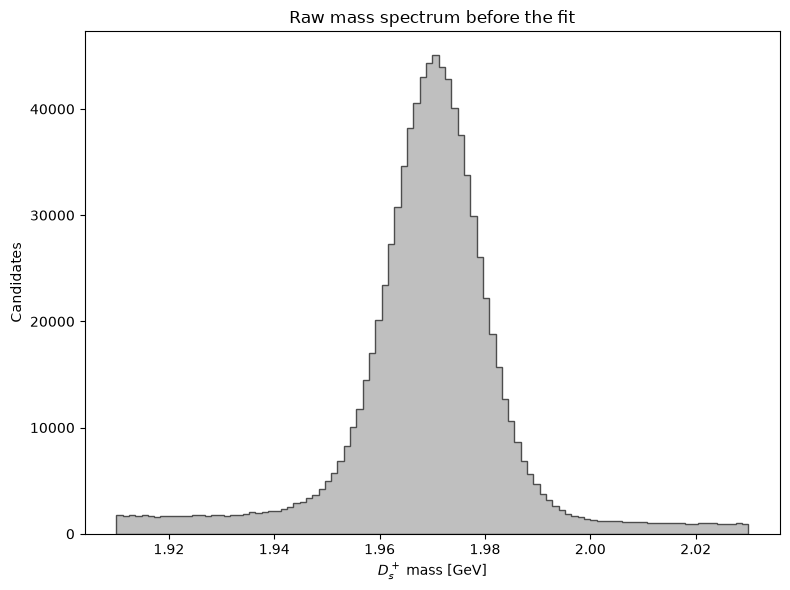

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(mass, bins=100, range=MASS_RANGE_GEV, histtype='stepfilled', color='0.75', edgecolor='0.3')
ax.set_xlabel(r'$D_s^+$ mass [GeV]')
ax.set_ylabel('Candidates')
ax.set_title('Raw mass spectrum before the fit')
fig.tight_layout()
plt.show()

## 5. Extended mass fit — Chapter 4 model

The mass fit follows the analysis-note parameterisation:

\[
P_s(m)=f_{CB}\,CB(m;\alpha,n,\mu_{CB},\sigma_{CB})
+(1-f_{CB})\,G(m;\mu_G,\sigma_G),
\]

with

\[
\mu_G=\mu_{CB}+\mu_{\mathrm{offset}},
\qquad
\sigma_G=\sigma_{CB}\,\sigma_{\mathrm{Ratio}},
\]

and an exponential background. All signal-shape parameters, the exponential slope, and the two extended yields are free. The numerical starting values below reproduce the central values from Table 11 where available; the background slope is only a numerical seed because it is not quoted in that table.


In [ ]:
MASS_LOW, MASS_HIGH = MASS_RANGE_GEV


def _truncated_crystalball_pdf(x, mu_cb, sigma_cb, alpha, n):
    distribution = crystalball(alpha, n, loc=mu_cb, scale=sigma_cb)
    normalization = distribution.cdf(MASS_HIGH) - distribution.cdf(MASS_LOW)
    return distribution.pdf(x) / normalization


def _truncated_gaussian_pdf(x, mu_g, sigma_g):
    distribution = norm(loc=mu_g, scale=sigma_g)
    normalization = distribution.cdf(MASS_HIGH) - distribution.cdf(MASS_LOW)
    return distribution.pdf(x) / normalization


def signal_mass_pdf(
    x,
    alpha,
    n,
    mu_cb,
    sigma_cb,
    mu_offset,
    sigma_ratio,
    f_cb,
):
    mu_g = mu_cb + mu_offset
    sigma_g = sigma_cb * sigma_ratio

    cb = _truncated_crystalball_pdf(x, mu_cb, sigma_cb, alpha, n)
    gauss = _truncated_gaussian_pdf(x, mu_g, sigma_g)
    return f_cb * cb + (1.0 - f_cb) * gauss


def background_mass_pdf(x, slope):
    x = np.asarray(x, dtype=float)
    width = MASS_HIGH - MASS_LOW
    if abs(slope) < 1e-10:
        return np.ones_like(x) / width

    # Equivalent to exp(slope * x), but shifted for numerical stability.
    normalization = np.expm1(slope * width)
    return slope * np.exp(slope * (x - MASS_LOW)) / normalization


def extended_mass_density(
    x,
    nsig,
    nbkg,
    alpha,
    n,
    mu_cb,
    sigma_cb,
    mu_offset,
    sigma_ratio,
    f_cb,
    slope,
):
    signal = signal_mass_pdf(
        x,
        alpha,
        n,
        mu_cb,
        sigma_cb,
        mu_offset,
        sigma_ratio,
        f_cb,
    )
    background = background_mass_pdf(x, slope)
    return nsig + nbkg, nsig * signal + nbkg * background


mass_nll = ExtendedUnbinnedNLL(mass, extended_mass_density)

# Table 11 central values, converted from MeV to GeV where appropriate.
mass_fit = Minuit(
    mass_nll,
    nsig=771_130.0,
    nbkg=129_288.0,
    alpha=1.681,
    n=11.0,
    mu_cb=1.96978,
    sigma_cb=0.01039,
    mu_offset=0.00098,
    sigma_ratio=0.6666,
    f_cb=0.52,
    slope=-5.0,
)

mass_fit.limits['nsig'] = (0.0, None)
mass_fit.limits['nbkg'] = (0.0, None)
mass_fit.limits['alpha'] = (0.05, 10.0)
mass_fit.limits['n'] = (1.01, 100.0)
mass_fit.limits['mu_cb'] = MASS_RANGE_GEV
mass_fit.limits['sigma_cb'] = (5e-4, 0.05)
mass_fit.limits['mu_offset'] = (-0.02, 0.02)
mass_fit.limits['sigma_ratio'] = (0.05, 5.0)
mass_fit.limits['f_cb'] = (0.0, 1.0)
mass_fit.limits['slope'] = (-100.0, 100.0)

mass_fit.migrad()
mass_fit.hesse()
print(mass_fit)


In [ ]:
mass_parameters = mass_fit.values.to_dict()

mu_g_fit = mass_parameters['mu_cb'] + mass_parameters['mu_offset']
sigma_g_fit = mass_parameters['sigma_cb'] * mass_parameters['sigma_ratio']
sigma_eff_fit = np.sqrt(
    mass_parameters['f_cb'] * mass_parameters['sigma_cb']**2
    + (1.0 - mass_parameters['f_cb']) * sigma_g_fit**2
)

print(f'mu_G       = {1e3 * mu_g_fit:.3f} MeV')
print(f'sigma_G    = {1e3 * sigma_g_fit:.3f} MeV')
print(f'sigma_eff  = {1e3 * sigma_eff_fit:.3f} MeV')
print(
    'legacy signal region (mu_CB +/- 2 sigma_eff): '
    f'[{1e3 * (mass_parameters["mu_cb"] - 2 * sigma_eff_fit):.1f}, '
    f'{1e3 * (mass_parameters["mu_cb"] + 2 * sigma_eff_fit):.1f}] MeV'
)

x_mass = np.linspace(MASS_LOW, MASS_HIGH, 1000)
signal_curve = signal_mass_pdf(
    x_mass,
    mass_parameters['alpha'],
    mass_parameters['n'],
    mass_parameters['mu_cb'],
    mass_parameters['sigma_cb'],
    mass_parameters['mu_offset'],
    mass_parameters['sigma_ratio'],
    mass_parameters['f_cb'],
)
background_curve = background_mass_pdf(x_mass, mass_parameters['slope'])

fig, ax = plt.subplots(figsize=(8, 6))
counts, edges, _ = ax.hist(
    mass,
    bins=120,
    range=MASS_RANGE_GEV,
    histtype='step',
    label='data',
)
bin_width = edges[1] - edges[0]
ax.plot(
    x_mass,
    bin_width * (
        mass_parameters['nsig'] * signal_curve
        + mass_parameters['nbkg'] * background_curve
    ),
    label='extended fit',
)
ax.plot(
    x_mass,
    bin_width * mass_parameters['nsig'] * signal_curve,
    '--',
    label='signal',
)
ax.plot(
    x_mass,
    bin_width * mass_parameters['nbkg'] * background_curve,
    '--',
    label='background',
)
ax.set(xlabel=r'$m(\pi^-\pi^+\pi^+)$ [GeV]', ylabel='Candidates / bin')
ax.legend()
plt.show()


## 6. COW signal weights

The fitted signal and background shapes are frozen and passed to `sweights.Cow`. The extended mass fit above was performed **after** the BDT, mass-range, and physical-Dalitz selections, so its $N_s$, $N_b$, fitted signal fraction, COW weights, and subsequent weighted Dalitz likelihood all refer to the same candidate sample.

We choose the fitted total mass density as the COW variance function,

\[
I(m)=f_s\,g_s(m)+(1-f_s)\,g_b(m),
\]

which gives the minimum-variance two-component COW/sWeight construction for the fitted mass model. The resulting signal weights may be negative.

The COW weights are **not** stored in `PhaseSpaceSample.weights`: those weights have integration/proposal semantics in Jax-PWA. They are passed separately to `WeightedUnbinnedNLL`.


In [ ]:
def fitted_signal_mass_pdf(x):
    return signal_mass_pdf(
        x,
        mass_parameters['alpha'],
        mass_parameters['n'],
        mass_parameters['mu_cb'],
        mass_parameters['sigma_cb'],
        mass_parameters['mu_offset'],
        mass_parameters['sigma_ratio'],
        mass_parameters['f_cb'],
    )


def fitted_background_mass_pdf(x):
    return background_mass_pdf(x, mass_parameters['slope'])


fitted_signal_fraction = (
    mass_parameters['nsig']
    / (mass_parameters['nsig'] + mass_parameters['nbkg'])
)


def fitted_total_mass_pdf(x):
    return (
        fitted_signal_fraction * fitted_signal_mass_pdf(x)
        + (1.0 - fitted_signal_fraction) * fitted_background_mass_pdf(x)
    )


cow = Cow(
    MASS_RANGE_GEV,
    fitted_signal_mass_pdf,
    fitted_background_mass_pdf,
    Im=fitted_total_mass_pdf,
    renorm=False,
)

signal_weights = np.asarray(cow(mass), dtype=float)
background_weights = np.asarray(cow(mass, idx=1), dtype=float)

print(f'sum signal COW weights     = {signal_weights.sum():,.1f}')
print(f'fitted signal yield         = {mass_parameters["nsig"]:,.1f}')
print(f'sum background COW weights = {background_weights.sum():,.1f}')
print(f'fitted background yield     = {mass_parameters["nbkg"]:,.1f}')
print(f'min/max signal weight       = {signal_weights.min():.4g}, {signal_weights.max():.4g}')
print(f'negative signal weights     = {np.count_nonzero(signal_weights < 0):,}')
print(f'sum w^2                     = {np.sum(signal_weights**2):,.1f}')
print(
    'N_eff =',
    f'{signal_weights.sum()**2 / np.sum(signal_weights**2):,.1f}',
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].scatter(mass, signal_weights, s=2, alpha=0.25)
axes[0].axhline(0.0, linewidth=1)
axes[0].set(
    xlabel=r'$m(\pi^-\pi^+\pi^+)$ [GeV]',
    ylabel='signal COW weight',
)
axes[1].hist(
    mass,
    bins=120,
    range=MASS_RANGE_GEV,
    weights=signal_weights,
    histtype='step',
    label='signal-weighted data',
)
axes[1].plot(
    x_mass,
    bin_width * signal_weights.sum() * fitted_signal_mass_pdf(x_mass),
    label='fitted signal shape',
)
axes[1].set(
    xlabel=r'$m(\pi^-\pi^+\pi^+)$ [GeV]',
    ylabel='Weighted candidates / bin',
)
axes[1].legend()
plt.show()


## 7. Pre-fit signal-model / COW-weighted-data comparison

The old signal+background toy comparison is replaced by a signal-only toy compared with the COW-weighted data. Histogram uncertainties use $\sqrt{\sum w_i^2}$ in each bin.


In [ ]:
published_start = {p.name: float(p.value) for p in model.parameters if not p.fixed}


def plot_weighted_projection_comparison(variable, generated, bins=60):
    observed = np.asarray(getattr(data, variable))
    generated_values = np.asarray(getattr(generated, variable))
    edges = np.linspace(
        min(observed.min(), generated_values.min()),
        max(observed.max(), generated_values.max()),
        bins + 1,
    )

    weighted_counts, _ = np.histogram(
        observed,
        bins=edges,
        weights=signal_weights,
    )
    weighted_variance, _ = np.histogram(
        observed,
        bins=edges,
        weights=signal_weights**2,
    )
    generated_counts, _ = np.histogram(generated_values, bins=edges)
    generated_counts = (
        generated_counts
        * signal_weights.sum()
        / max(generated_counts.sum(), 1)
    )

    centers = 0.5 * (edges[:-1] + edges[1:])
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.errorbar(
        centers,
        weighted_counts,
        yerr=np.sqrt(weighted_variance),
        fmt='o',
        markersize=3,
        label='COW-weighted data',
    )
    ax.stairs(generated_counts, edges, label='prefit signal toy')
    ax.set(
        xlabel='$' + variable + '$ [GeV$^2$]',
        ylabel='Weighted candidates',
    )
    ax.legend()
    plt.show()


if RUN_PREFIT_TOY_COMPARISON:
    prefit_toy = generate_toy(
        model,
        max(1, int(round(signal_weights.sum()))),
        parameters=published_start,
        efficiency=efficiency,
        seed=TOY_SEED,
    )

    for variable in ('s12', 's13', 's23'):
        plot_weighted_projection_comparison(variable, prefit_toy)


## 8. Weighted Dalitz fit

The `FitSession` is signal-only and minimizes

\[
Q(\theta)=-\sum_i w_i\log p(x_i\mid\theta).
\]

For the parameter uncertainties we use the **Godambe/sandwich covariance**,

\[
A=-\sum_i w_i\,\partial_\theta^2\log p_i,
\qquad
B=\sum_i w_i^2 s_i s_i^T,
\qquad
s_i=\partial_\theta\log p_i,
\]

\[
\boxed{C_{\rm sandwich}=A^{-1}BA^{-1}}.
\]

This differs from the older squared-weight-Hessian / SumW2 prescription, which replaces $B$ by $H_{w^2}=-\sum_iw_i^2\partial_\theta^2\log p_i$. The score-outer-product form is the general asymptotic M-estimator covariance for fixed weights; see C. Langenbruch, *Eur. Phys. J. C* **82** (2022) 393, arXiv:1911.01303, and H. Dembinski *et al.*, *Nucl. Instrum. Meth. A* **1040** (2022) 167270, arXiv:2112.04574.

For this notebook, the mass-fit/COW weights are treated as fixed in the Dalitz covariance. This does **not yet** include the additional first-stage uncertainty and correlations from estimating the mass-fit yields and shape parameters on the same sample. The full two-step COW estimating-equation treatment is discussed by Dembinski *et al.*, especially Eqs. (33--35).

Jax-PWA evaluates $B$ without constructing the full event-by-parameter score matrix. At the fitted point $\hat\theta$ it forms

\[
R(\theta)=\frac12\sum_iw_i^2
\left[\log p_i(\theta)-\log p_i(\hat\theta)\right]^2,
\]

for which $\nabla^2R(\hat\theta)=B$ exactly, and reuses the memory-aware JAX Hessian/HVP backend.

With `covariance="sandwich"` and `hessian="jax"`, MIGRAD still uses the JAX gradient but numerical search curvature; the exact JAX matrices are evaluated only after convergence. This avoids injecting an indefinite signed-weight Hessian into MIGRAD away from the minimum.

There is no `BackgroundSpec`, no sideband histogram, and no fixed signal fraction in the Dalitz likelihood.


In [ ]:
session = FitSession(
    model,
    data,
    efficiency=efficiency,
)

weighted_nll = WeightedUnbinnedNLL(
    session._cached_signal_logpdf,
    data.as_dict(),
    jnp.asarray(signal_weights),
)

start = dict(published_start)

start_logpdf = np.asarray(
    session._cached_signal_logpdf(data.as_dict(), start)
)
start_acceptance = np.asarray(session.acceptance_data)
nonfinite_logpdf = ~np.isfinite(start_logpdf)

print('Dalitz likelihood support diagnostic:')
print(f'  events                  = {data.size:,}')
print(f'  zero acceptance         = {np.count_nonzero(start_acceptance <= 0):,}')
print(f'  non-finite logpdf       = {np.count_nonzero(nonfinite_logpdf):,}')
print(f'  finite signal weights   = {np.count_nonzero(np.isfinite(signal_weights)):,}/{signal_weights.size:,}')

if np.any(~np.isfinite(signal_weights)):
    raise RuntimeError('COW signal weights contain non-finite values')

if np.any(nonfinite_logpdf):
    bad = np.flatnonzero(nonfinite_logpdf)
    print('First events with non-finite signal logpdf:')
    for idx in bad[:10]:
        print(
            f'  i={idx:7d}  m={mass[idx]:.6f}  '
            f's12={float(data.s12[idx]):.6f}  '
            f's13={float(data.s13[idx]):.6f}  '
            f's23={float(data.s23[idx]):.6f}  '
            f'eff={start_acceptance[idx]:.6g}  '
            f'w={signal_weights[idx]:+.4f}'
        )
    raise RuntimeError(
        'Signal logpdf is non-finite after the physical-Dalitz selection; '
        'inspect the efficiency/amplitude diagnostics above before running Minuit.'
    )

weighted_nll_start = float(weighted_nll(start))
print('Weighted NLL at published start:', weighted_nll_start)
if not np.isfinite(weighted_nll_start):
    raise RuntimeError('Weighted NLL is not finite at the published starting point')

if RUN_FIT:
    result = session.fit(
        start,
        weights=jnp.asarray(signal_weights),
        covariance='sandwich',
        strategy=1,
        hesse=False,
        simplex=False,
        hessian='jax',
        hessian_batch_size=1,
        ncall=250_000,
        tolerance=1e-4,
        verbose=3,
    )


## 9. Weighted-fit diagnostics

The ordinary `session.plot_projection()` currently displays unweighted data, so the diagnostic projections below explicitly histogram the data with the COW weights and use $\sqrt{\sum w_i^2}$ errors. The smooth model projection is generated from the fitted signal model and scaled to $\sum_i w_i$.


In [ ]:
def plot_weighted_fit_projection(result, variable, bins=60, projection_size=500_000):
    values = session.result_values(result)
    observed = np.asarray(getattr(data, variable))
    edges = np.linspace(observed.min(), observed.max(), bins + 1)

    weighted_counts, _ = np.histogram(
        observed,
        bins=edges,
        weights=signal_weights,
    )
    weighted_variance, _ = np.histogram(
        observed,
        bins=edges,
        weights=signal_weights**2,
    )

    projection_sample = session._get_projection_sample(projection_size, TOY_SEED)
    total = np.zeros(bins, dtype=float)
    components = []
    for name, component_sample, component_weights in session._projection_components(
        values,
        projection_sample,
    ):
        component_values = np.asarray(getattr(component_sample, variable))
        counts, _ = np.histogram(
            component_values,
            bins=edges,
            weights=np.asarray(component_weights),
        )
        total += counts
        components.append((name, counts))

    scale = signal_weights.sum() / max(total.sum(), 1e-300)
    centers = 0.5 * (edges[:-1] + edges[1:])

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.errorbar(
        centers,
        weighted_counts,
        yerr=np.sqrt(weighted_variance),
        fmt='o',
        markersize=3,
        label='COW-weighted data',
    )
    for name, counts in components:
        ax.stairs(scale * counts, edges, label=name, alpha=0.65)
    ax.stairs(scale * total, edges, label='total fit', linewidth=2)
    ax.set(
        xlabel='$' + variable + '$ [GeV$^2$]',
        ylabel='Weighted candidates',
    )
    ax.legend(fontsize='small')
    plt.show()


if RUN_FIT:
    values = session.result_values(result)
    print('Weighted NLL fit:', float(weighted_nll(values)))
    session.print_fit_fractions(
        result,
        acceptance_weighted=False,
        include_interference=True,
        precision=4,
    )

    fit_mag = np.array([values[f'S.mag_{i:02d}'] for i in range(50)])
    fit_phase = np.array([values[f'S.phase_{i:02d}'] for i in range(50)])
    paper_complex = QMI_MAGNITUDE_PAPER * np.exp(1j * QMI_PHASE_RAD_START)
    fit_complex = fit_mag * np.exp(1j * fit_phase)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    axes[0].plot(QMI_KNOTS_GEV, QMI_MAGNITUDE_PAPER, 'o', label='paper start')
    axes[0].plot(QMI_KNOTS_GEV, fit_mag, '-', label='weighted fit')
    axes[0].set(xlabel=r'$m(\pi^+\pi^-)$ [GeV]', ylabel='magnitude')
    axes[0].legend()

    axes[1].plot(
        QMI_KNOTS_GEV,
        np.rad2deg(QMI_PHASE_RAD_START),
        'o',
        label='paper start',
    )
    axes[1].plot(
        QMI_KNOTS_GEV,
        np.rad2deg(fit_phase),
        '-',
        label='weighted fit',
    )
    axes[1].set(xlabel=r'$m(\pi^+\pi^-)$ [GeV]', ylabel='phase [deg]')
    axes[1].legend()

    axes[2].plot(
        paper_complex.real,
        paper_complex.imag,
        'o',
        label='paper start',
    )
    axes[2].plot(
        fit_complex.real,
        fit_complex.imag,
        '-',
        label='weighted fit',
    )
    axes[2].set(xlabel=r'Re $A_S$', ylabel=r'Im $A_S$')
    axes[2].legend()
    plt.show()

    for variable in ('s12', 's13', 's23'):
        plot_weighted_fit_projection(result, variable, bins=60)
